In [2]:
import jax.numpy as jnp
from jax import random
import jax
from flax.training import train_state
import optax
from flax import linen as nn
from tqdm.notebook import tqdm
# Optionally, you can save the losses to a file or plot them
import matplotlib.pyplot as plt
import numpy as np
from jax.example_libraries import optimizers
import sys


In [3]:
# Figure 3(a) and 3(b). Sweep over alpha and epsilon.

def phi(z, eps = 0.25):
    return z + 0.5*eps*z**2

def NN_func(params,X, alpha, eps=0.25):
    _, W = params

    D = W.shape[1]
    N = W.shape[0]

    h = W @ X / jnp.sqrt(D)
    f = alpha * jnp.mean( phi(h, eps = eps), axis = 0)
    return f


def target_fn(beta, X):
    return (X.T @ beta / jnp.sqrt(D))**2


D = 100
P = 450
N = 500

X = random.normal(random.PRNGKey(0), (D,P))
Xt = random.normal(random.PRNGKey(1), (D,1000))
beta = random.normal(random.PRNGKey(2), (D,))

y = target_fn(beta, X)
yt = target_fn(beta,Xt)

a = random.normal(random.PRNGKey(0), (N, ))
W = random.normal(random.PRNGKey(0), (N, D))
params = [a, W]


eta = 0.5 * N
# opt_init, opt_update, _ = optimizers.sgd(eta)
def opt_init(params):
    return params

def opt_update(step, grads, params):
    return jax.tree_util.tree_map(lambda p, g: p - eta * g, params, grads)

alphas = [2**(-5),0.25,0.5,1.0,2.0,4.0,8.0,16,32]
# alphas = [2**(-5),0.25]

all_tr_losses = []
all_te_losses = []


for alpha in alphas:
    opt_state = opt_init(params)


    loss_fn = jax.jit(
        lambda p, X, y: 
        jnp.mean( ( NN_func(p, X,alpha)- NN_func(params,X,alpha) - y )**2 / alpha**2 )
    )

    grad_loss = jax.jit(jax.grad(loss_fn,0))
    tr_losses = []
    te_losses = []
    for t in tqdm(range(60000)):
        opt_state = opt_update(t, grad_loss(opt_state, X, y), opt_state)
        
        if t % 2 == 0:
            train_loss = alpha**2*loss_fn(opt_state, X, y)
            test_loss = alpha**2*loss_fn(opt_state, Xt, yt)
            tr_losses += [train_loss]
            te_losses += [test_loss]
            sys.stdout.write(f'\r t: {t} | train loss: {train_loss} | test loss: {test_loss}')

        if t % 10000 == 0:
            print(" ")


    all_tr_losses += [tr_losses]
    all_te_losses += [te_losses]

plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.464644193649292 | test loss: 3.5249645709991455 
 t: 10000 | train loss: 1.4675851161882747e-05 | test loss: 0.0069425832480192184 
 t: 20000 | train loss: 3.2356563224311685e-06 | test loss: 0.0034094578586518764 
 t: 30000 | train loss: 1.1581372518776334e-06 | test loss: 0.0023605162277817726 
 t: 40000 | train loss: 5.059149543740205e-07 | test loss: 0.0018817851087078452 
 t: 50000 | train loss: 2.4620402427899535e-07 | test loss: 0.001619058893993497 
 t: 59998 | train loss: 1.2810839677968033e-07 | test loss: 0.0014566660393029451

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.466268539428711 | test loss: 3.525581121444702 
 t: 10000 | train loss: 0.00025368324713781476 | test loss: 0.12096352130174637 
 t: 20000 | train loss: 5.072798740002327e-05 | test loss: 0.07459349930286407 
 t: 30000 | train loss: 1.6117746781674214e-05 | test loss: 0.05927557498216629 
 t: 40000 | train loss: 6.170195320009952e-06 | test loss: 0.052013199776411057 
 t: 50000 | train loss: 2.605521103760111e-06 | test loss: 0.04798189923167229 6
 t: 59998 | train loss: 1.1664318435578025e-06 | test loss: 0.045546393841505056

  0%|          | 0/60000 [00:00<?, ?it/s]

...

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4664716720581055 | test loss: 3.525651693344116 
 t: 10000 | train loss: 0.003037344664335251 | test loss: 0.8857734799385071 
 t: 20000 | train loss: 0.0004389885871205479 | test loss: 0.7268863916397095 
 t: 30000 | train loss: 0.0001024857338052243 | test loss: 0.671994149684906 6
 t: 40000 | train loss: 2.8951770218554884e-05 | test loss: 0.6473904848098755 
 t: 50000 | train loss: 9.023652637552004e-06 | test loss: 0.6350309252738953 
 t: 59998 | train loss: 2.9787381663481938e-06 | test loss: 0.6284248828887947

  0%|          | 0/60000 [00:00<?, ?it/s]

 t: 0 | train loss: 3.4664859771728516 | test loss: 3.525662422180176 
 t: 6888 | train loss: 0.015813129022717476 | test loss: 1.4388350248336792

KeyboardInterrupt: 

In [ ]:
print('hi')

hi


0.03125
0.25
0.5
1.0
2.0
4.0
8.0
16


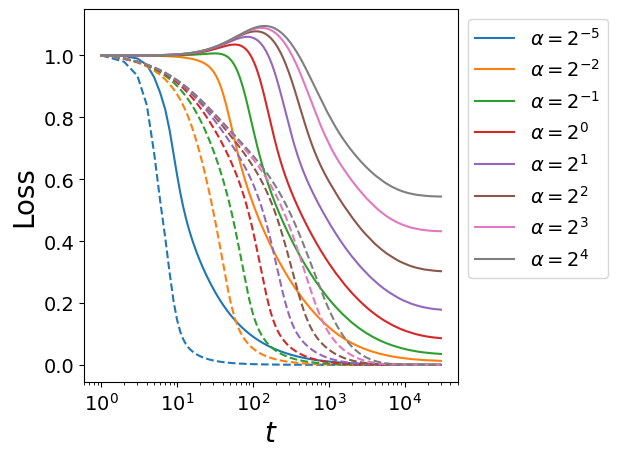

In [3]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:-1]):
    print(alpha)
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7efe17ff46d0>>
Traceback (most recent call last):
  File "/home/sjiang/Documents/precond-gd/.venv/lib64/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


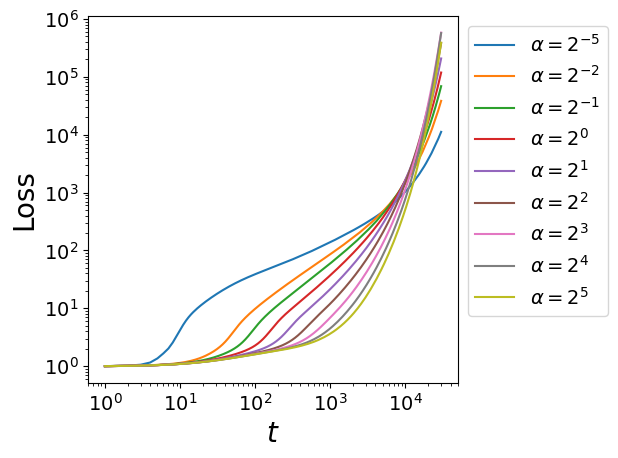

In [5]:
plt.rcParams.update({'font.size': 14})
plt.figure()
for i,alpha in enumerate(alphas[:]):
    # plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_tr_losses[i]) / all_tr_losses[i][0], '--',  color = f'C{i}')
    # plt.plot(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), jnp.array(all_te_losses[i]) / all_te_losses[i][0],  color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha))

    plt.loglog(jnp.linspace(1,len(all_tr_losses[i]),len(all_tr_losses[i])), 
             (jnp.array(all_te_losses[i]) / all_te_losses[i][0]) / (jnp.array(all_tr_losses[i]) / all_tr_losses[i][0]) ,  
             color = f'C{i}', label = r'$\alpha = 2^{%0.0f}$' % jnp.log2(alpha)
    )
    print(alpha)
plt.xscale('log')
plt.xlabel(r'$t$',fontsize = 20)
plt.ylabel('Loss',fontsize = 20)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

